[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Seminar%2003/Seminar03.ipynb)

In [ ]:
pip install --upgrade yfinance


In [11]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from datetime import datetime, timedelta
import matplotlib.dates as mdates

In [25]:
# Define stocks and download data
stocks = ['META', 'AMZN', 'NFLX']  # Meta, Amazon, Netflix
end_date = '2025-03-01'
start_date = (datetime.strptime(end_date, '%Y-%m-%d') - timedelta(days=5*365)).strftime('%Y-%m-%d')

data = yf.download(stocks, start=start_date, end=end_date)

[*********************100%***********************]  3 of 3 completed


In [21]:
print(data)

Price            Close                                High              \
Ticker            AMZN        META        NFLX        AMZN        META   
Date                                                                     
2019-03-04   84.808502  166.733093  351.040009   85.471497  166.862603   
2019-03-05   84.621498  170.608276  354.299988   85.389999  171.225927   
2019-03-06   83.447502  171.853531  359.609985   84.887497  172.909510   
2019-03-07   81.297501  168.486389  352.600006   83.487503  171.086458   
2019-03-08   81.040001  168.954605  349.600006   81.136002  168.974518   
...                ...         ...         ...         ...         ...   
2025-02-24  212.710007  668.130005  988.469971  217.720001  687.270020   
2025-02-25  212.800003  657.500000  977.239990  213.339996  668.000000   
2025-02-26  214.350006  673.700012  990.059998  218.160004  683.010010   
2025-02-27  208.740005  658.239990  963.070007  219.970001  688.650024   
2025-02-28  212.279999  668.200012  98

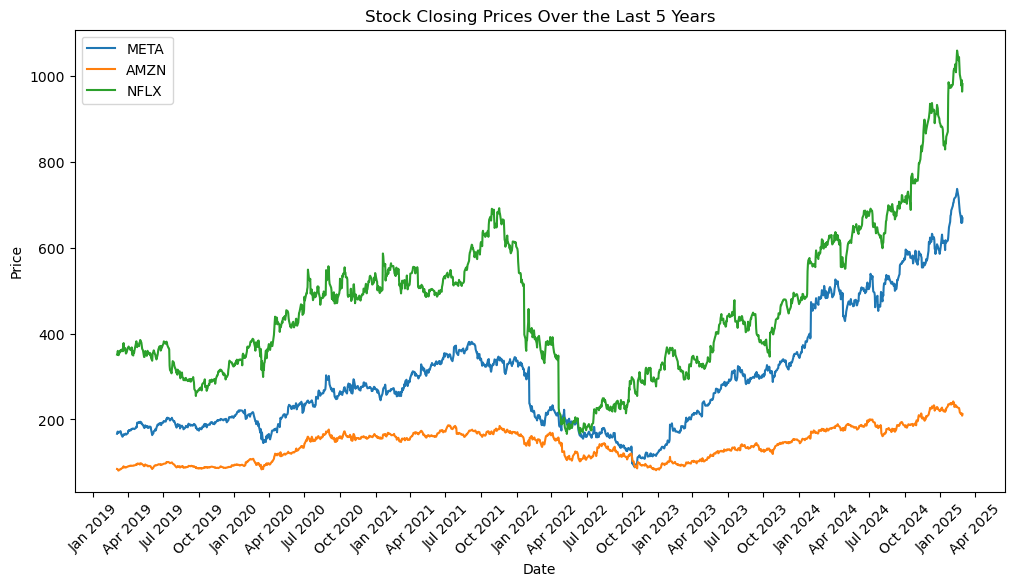

In [23]:
# Plot the closing prices of each stock
plt.figure(figsize=(12, 6))
for stock in stocks:
    plt.plot(data.index, data['Close'][stock], label=stock)

# Format x-axis to show months clearly
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Jan 2025'
plt.xticks(rotation=45)

plt.legend()
plt.title("Stock Closing Prices Over the Last 5 Years")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [44]:
# Compute log returns
log_returns = np.log(data['Close'] / data['Close'].shift(1))

In [45]:
# Display log returns
print("Log Returns:")
print(log_returns.tail())

Log Returns:
Ticker          AMZN      META      NFLX
Date                                    
2025-02-24 -0.018030 -0.022817 -0.014742
2025-02-25  0.000423 -0.016038 -0.011426
2025-02-26  0.007257  0.024340  0.013033
2025-02-27 -0.026521 -0.023215 -0.027639
2025-02-28  0.016817  0.015018  0.017998


In [49]:
# Define colors for consistency
colors = {stocks[0]: 'tab:blue', stocks[1]: 'tab:orange', stocks[2]: 'tab:green'}

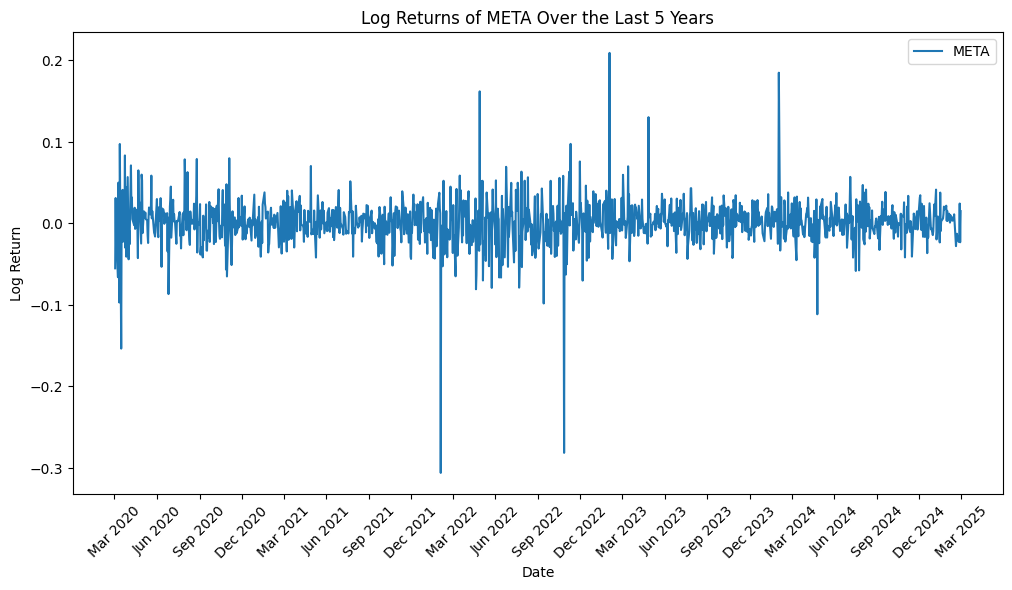

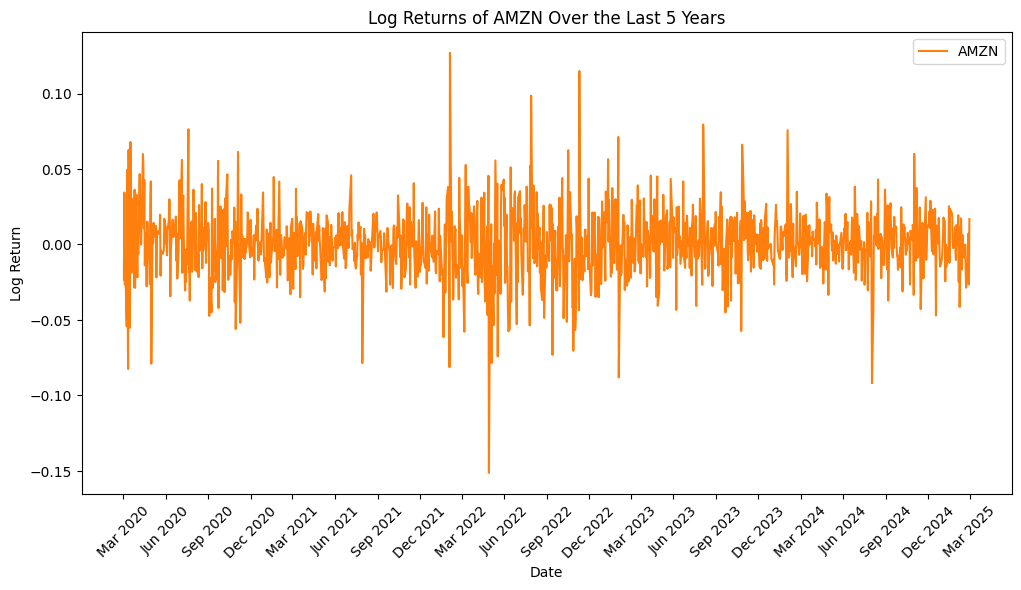

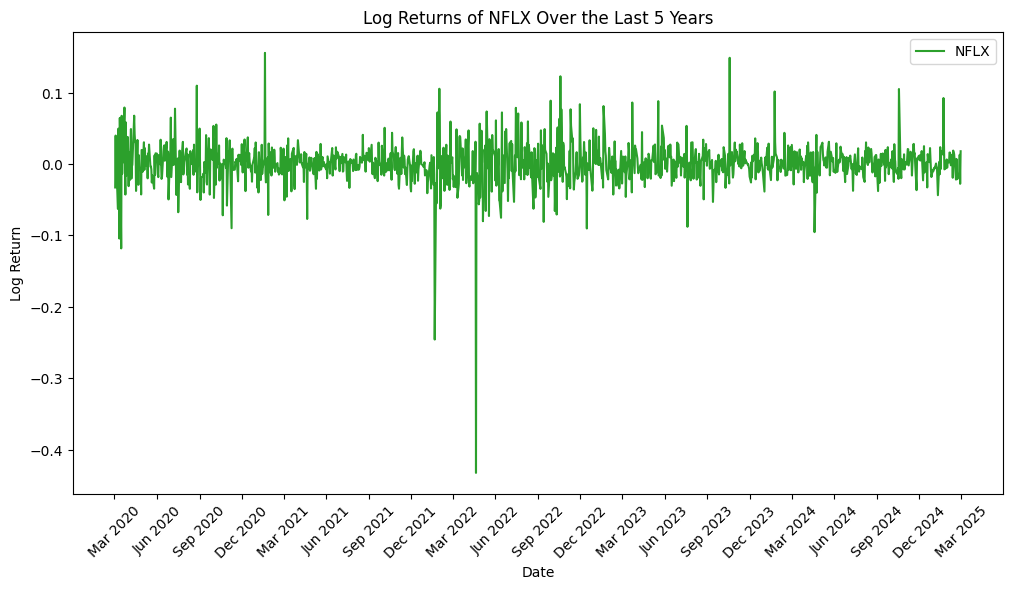

In [50]:
# Plot log returns for each stock separately
for stock in stocks:
    plt.figure(figsize=(12, 6))
    plt.plot(log_returns.index, log_returns[stock], label=stock, color=colors[stock])
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Show every 3 months
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    plt.legend()
    plt.title(f"Log Returns of {stock} Over the Last 5 Years")
    plt.xlabel("Date")
    plt.ylabel("Log Return")
    plt.show()


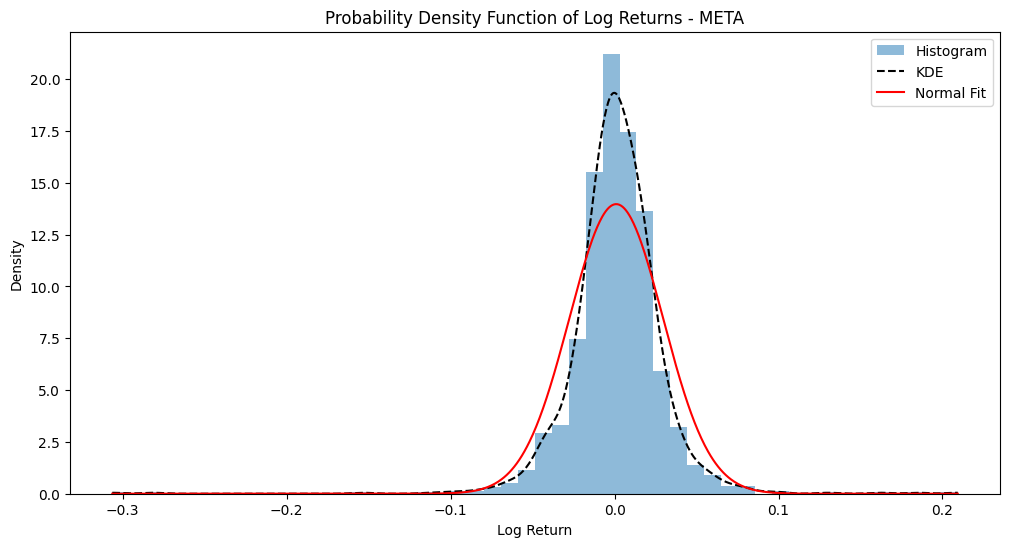

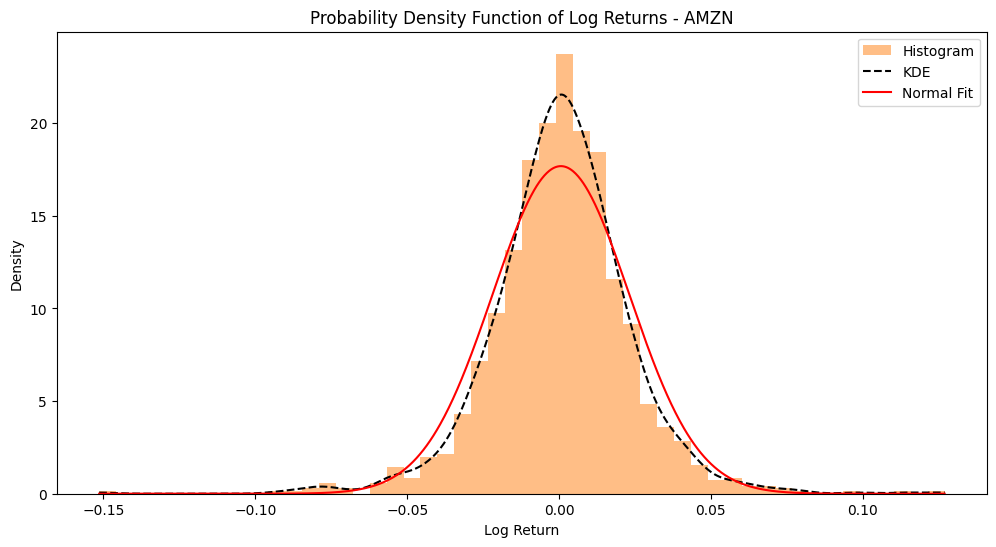

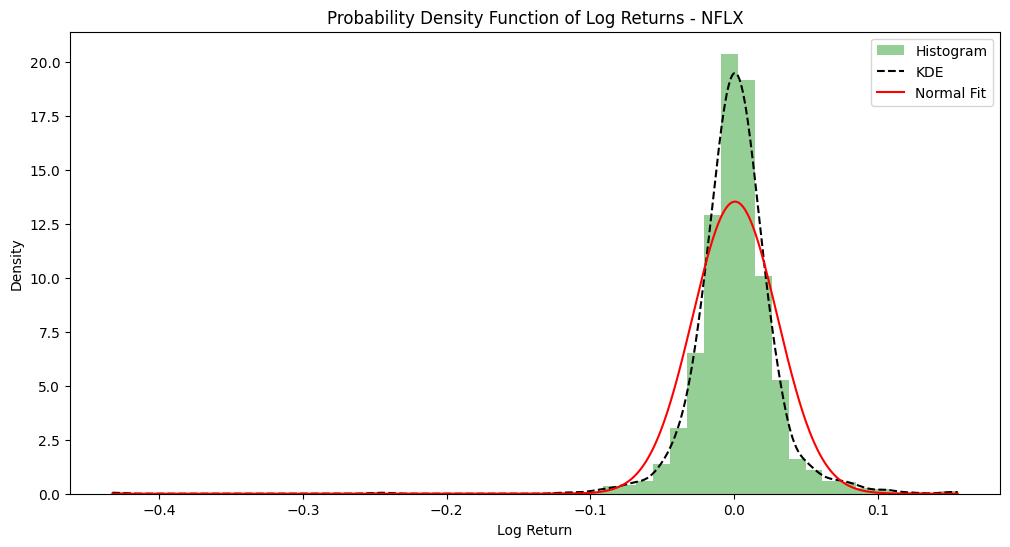

In [53]:
# Compute and plot Probability Density Function (PDF) for each stock
for stock in stocks:
    plt.figure(figsize=(12, 6))

    # Get log return values, drop NaNs
    stock_returns = log_returns[stock].dropna()

    # Kernel Density Estimation (KDE)
    kde = stats.gaussian_kde(stock_returns)
    x_vals = np.linspace(stock_returns.min(), stock_returns.max(), 1000)
    kde_vals = kde(x_vals)

    # Normal distribution fit
    mu, sigma = stock_returns.mean(), stock_returns.std()
    norm_vals = stats.norm.pdf(x_vals, mu, sigma)

    # Plot histogram and density functions
    plt.hist(stock_returns, bins=50, density=True, alpha=0.5, label="Histogram", color=colors[stock])
    plt.plot(x_vals, kde_vals, label="KDE", color='black', linestyle='dashed')
    plt.plot(x_vals, norm_vals, label="Normal Fit", color='red', linestyle='solid')

    plt.title(f"Probability Density Function of Log Returns - {stock}")
    plt.xlabel("Log Return")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

In [54]:
# Compute skewness and kurtosis
skewness = log_returns.skew()
kurtosis = log_returns.kurtosis()
print("\nSkewness:")
print(skewness)
print("\nKurtosis:")
print(kurtosis)


Skewness:
Ticker
AMZN   -0.149221
META   -1.234934
NFLX   -2.633097
dtype: float64

Kurtosis:
Ticker
AMZN     4.103380
META    23.306885
NFLX    42.502946
dtype: float64


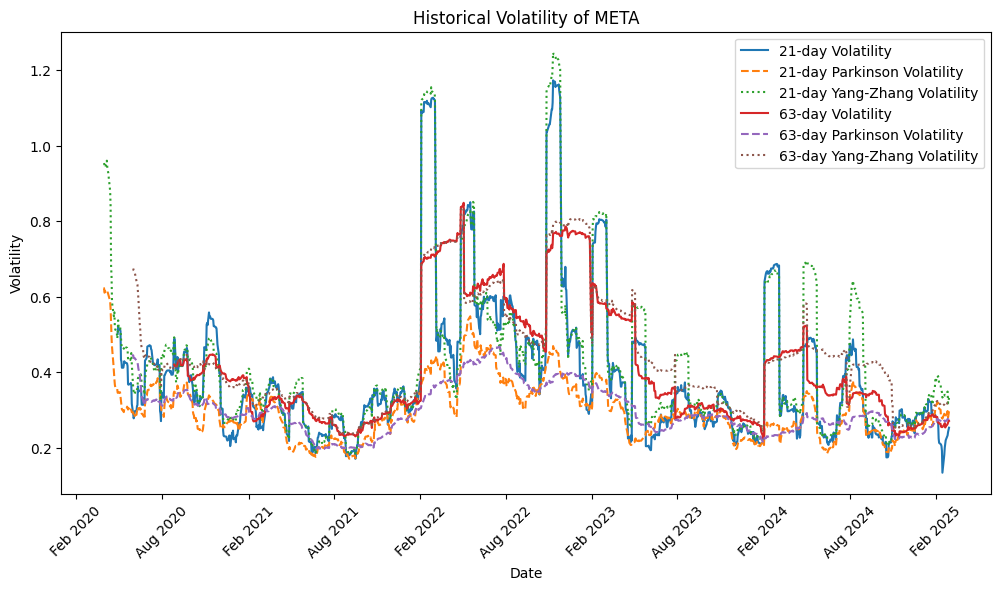

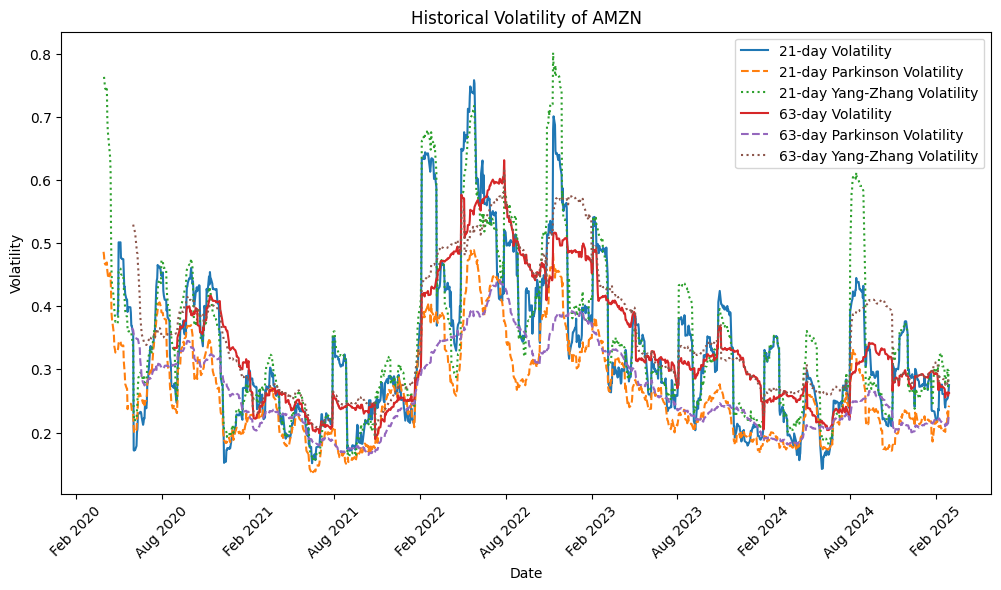

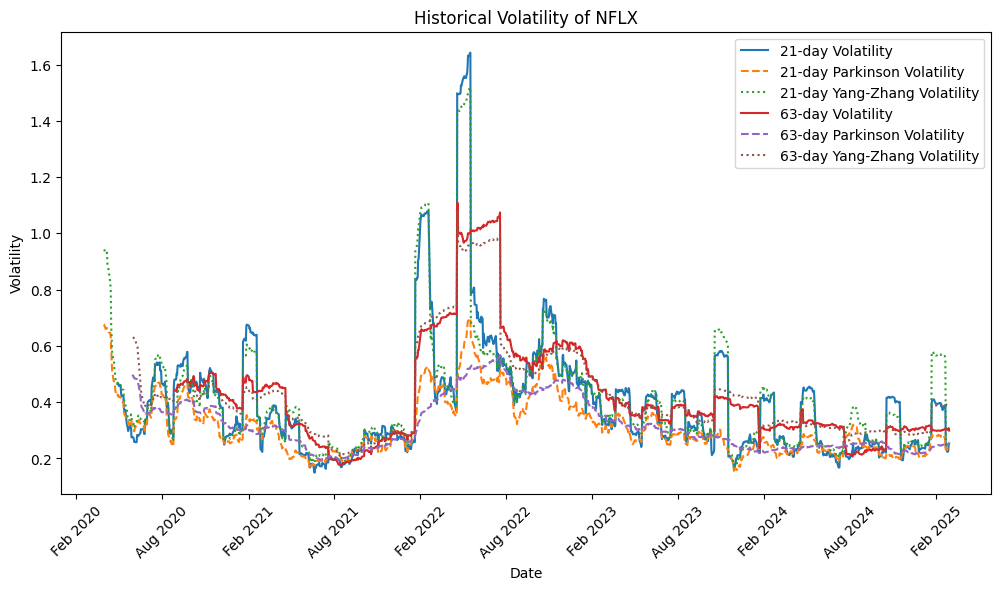

In [65]:
# Compute historical volatility using the standard deviation formula
def compute_historical_volatility(returns, window):
    """Computes historical volatility using the given formula."""
    rolling_mean = returns.rolling(window=window).mean()
    squared_diff = (returns - rolling_mean) ** 2
    variance = squared_diff.rolling(window=window).sum() / (window - 1)
    return np.sqrt(variance) * np.sqrt(252)  # Annualized volatility

# Compute Parkinson's volatility estimator
def compute_parkinson_volatility(high, low, window):
    """Computes Parkinson's volatility estimator."""
    log_hl = np.log(high / low)
    variance = (1 / (4 * np.log(2))) * (log_hl ** 2)
    parkinson_vol = np.sqrt(variance.rolling(window=window).mean()) * np.sqrt(252)  # Annualized
    return parkinson_vol

# Compute Yang-Zhang volatility estimator
def compute_yang_zhang_volatility(open_, high, low, close, window):
    """Computes Yang-Zhang volatility estimator."""
    log_oc = np.log(open_ / close.shift(1))  # Overnight volatility
    log_cc = np.log(close / close.shift(1))  # Close-to-close volatility
    log_hl = np.log(high / low)  # High-Low range

    k = 0.34 / (1.34 + (window + 1) / (window - 1))  # Weighting factor
    sigma_oc = log_oc.rolling(window=window).std()
    sigma_cc = log_cc.rolling(window=window).std()
    sigma_hl = (1 / (4 * np.log(2))) * (log_hl ** 2)
    sigma_hl = np.sqrt(sigma_hl.rolling(window=window).mean())

    yang_zhang_vol = np.sqrt(sigma_oc**2 + k * sigma_cc**2 + (1 - k) * sigma_hl**2) * np.sqrt(252)  # Annualized
    return yang_zhang_vol

# Compute historical volatility using different window frames
window_sizes = [21, 63]  # 1-month, 3-months, 6-months, 1-year
volatility = {window: compute_historical_volatility(log_returns, window) for window in window_sizes}
parkinson_volatility = {window: compute_parkinson_volatility(data['High'], data['Low'], window) for window in window_sizes}
yang_zhang_volatility = {window: compute_yang_zhang_volatility(data['Open'], data['High'], data['Low'], data['Close'], window) for window in window_sizes}

# Plot historical volatility for each stock and window size
for stock in stocks:
    plt.figure(figsize=(12, 6))
    for window in window_sizes:
        plt.plot(volatility[window].index, volatility[window][stock], label=f'{window}-day Volatility', linestyle='solid')
        plt.plot(parkinson_volatility[window].index, parkinson_volatility[window][stock], label=f'{window}-day Parkinson Volatility', linestyle='dashed')
        plt.plot(yang_zhang_volatility[window].index, yang_zhang_volatility[window][stock], label=f'{window}-day Yang-Zhang Volatility', linestyle='dotted')

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # Show every 6 months
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    plt.legend()
    plt.title(f"Historical Volatility of {stock}")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.show()

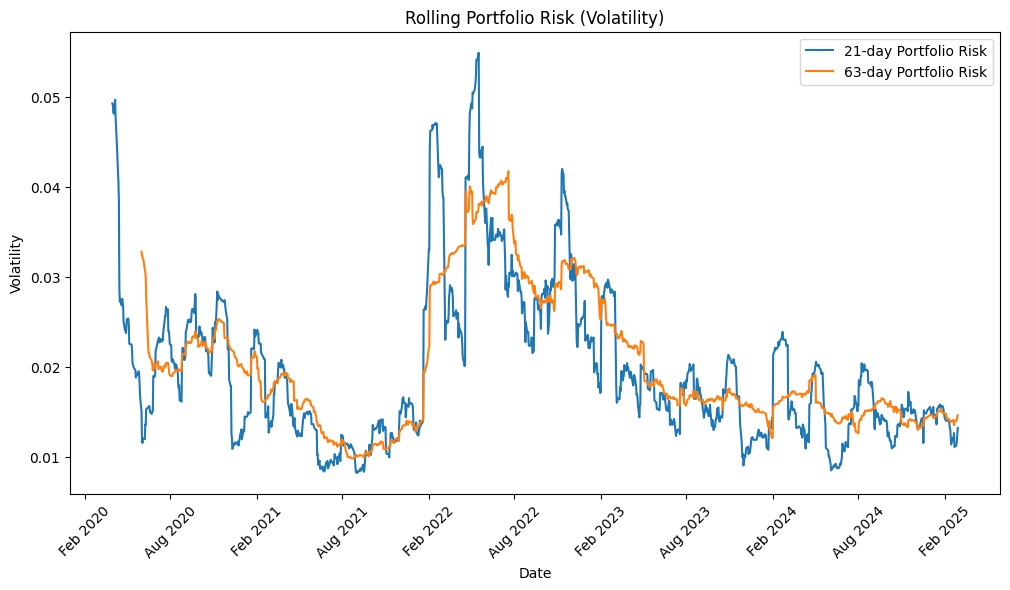

In [69]:
# Compute rolling portfolio risk
def compute_rolling_portfolio_risk(log_returns, weights, window):
    """Computes rolling portfolio risk using a given window size."""
    rolling_cov_matrix = log_returns.rolling(window=window).cov()
    rolling_volatility = rolling_cov_matrix.groupby(level=0).apply(lambda x: np.sqrt(weights.T @ x @ weights))
    return rolling_volatility

rolling_portfolio_risk = {window: compute_rolling_portfolio_risk(log_returns, np.array([0.4, 0.3, 0.3]), window) for window in window_sizes}

# Plot rolling portfolio risk
plt.figure(figsize=(12, 6))
for window in window_sizes:
    plt.plot(rolling_portfolio_risk[window].index, rolling_portfolio_risk[window], label=f'{window}-day Portfolio Risk')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.title("Rolling Portfolio Risk (Volatility)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

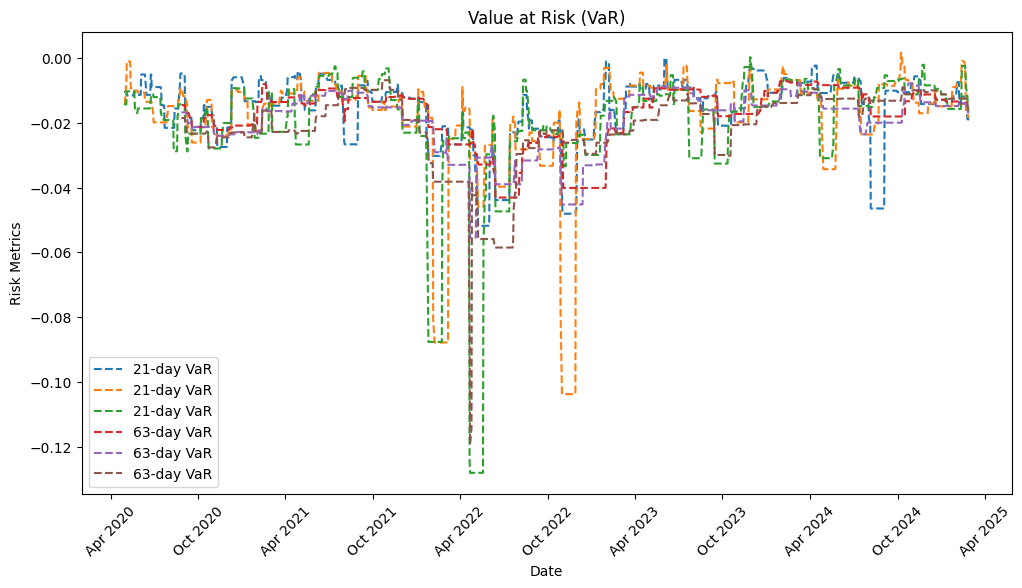

In [77]:
def compute_var(log_returns, weights, window, alpha=0.05):
    """Computes rolling Value at Risk (VaR) using historical simulation method."""
    rolling_portfolio_returns = log_returns.rolling(window=window).apply(
        lambda x: np.dot(weights, x[-3:]), raw=True  # Extracts only the last row (latest log return)
    )
    var = rolling_portfolio_returns.rolling(window=window).quantile(alpha, interpolation='linear')
    return var
rolling_var = {window: compute_var(log_returns, np.array([0.4, 0.3, 0.3]), window) for window in window_sizes}
# Plot rolling portfolio risk and VaR
plt.figure(figsize=(12, 6))
for window in window_sizes:
    plt.plot(rolling_var[window].index, rolling_var[window], label=f'{window}-day VaR', linestyle='dashed')
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.title("Value at Risk (VaR)")
plt.xlabel("Date")
plt.ylabel("Risk Metrics")
plt.show()


Backtest Results (VaR Exceedances):
21-day Window: 62 times where actual loss exceeded VaR
63-day Window: 77 times where actual loss exceeded VaR


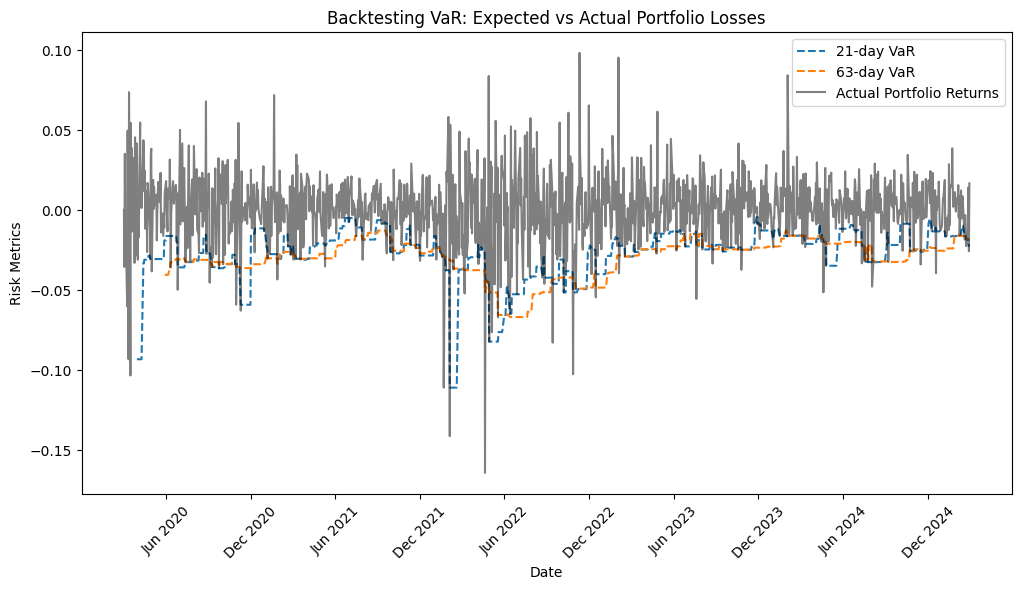

In [82]:
# Compute Value at Risk (VaR) at 95% confidence level
def compute_var(log_returns, weights, window, alpha=0.05):
    """Computes rolling Value at Risk (VaR) using historical simulation method."""
    rolling_portfolio_returns = log_returns.mul(weights, axis=1).sum(axis=1).rolling(window=window)
    var = rolling_portfolio_returns.quantile(alpha, interpolation='linear')
    return var

rolling_var = {window: compute_var(log_returns, np.array([0.4, 0.3, 0.3]), window) for window in window_sizes}

# Backtest VaR
exceedances = {}
actual_losses = log_returns.mul(np.array([0.4, 0.3, 0.3]), axis=1).sum(axis=1)
for window in window_sizes:
    exceedances[window] = (actual_losses < rolling_var[window]).sum()

# Print backtest results
print("\nBacktest Results (VaR Exceedances):")
for window in window_sizes:
    print(f"{window}-day Window: {exceedances[window]} times where actual loss exceeded VaR")

# Plot rolling VaR and actual portfolio returns
plt.figure(figsize=(12, 6))
for window in window_sizes:
    plt.plot(rolling_var[window].index, rolling_var[window], label=f'{window}-day VaR', linestyle='dashed')
plt.plot(actual_losses.index, actual_losses, label='Actual Portfolio Returns', color='black', alpha=0.5)
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend()
plt.title("Backtesting VaR: Expected vs Actual Portfolio Losses")
plt.xlabel("Date")
plt.ylabel("Risk Metrics")
plt.show()